In [34]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import sklearn
import sys
from glob import glob
from itertools import cycle
import seaborn as sns


sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

Explore Guitar Files
-Sample rate can be considered the resolution of the audio
Lets read in the audio files:

In [81]:
audioFiles = glob("./Training/*/*.wav")
print(audioFiles[200])


./Training\Bb\Bb_AcusticPlug11_1.wav


In [94]:
ipd.Audio(audioFiles[200])

Y represents the raw data of the audio file and sr an integer value of the saple rate

In [82]:
y, sr = librosa.load(audioFiles[200])
print(f"y: {y[:10]}")
print(f"Shape y: {y.shape}")
print(f"sr: {sr}")

y: [ 7.39153620e-06 -2.76383071e-05 -8.99253209e-05 -1.62854034e-04
 -1.74410510e-04 -1.15558214e-04  2.86950817e-05  1.92887645e-04
  2.37142958e-04  1.90915889e-04]
Shape y: (98190,)
sr: 22050


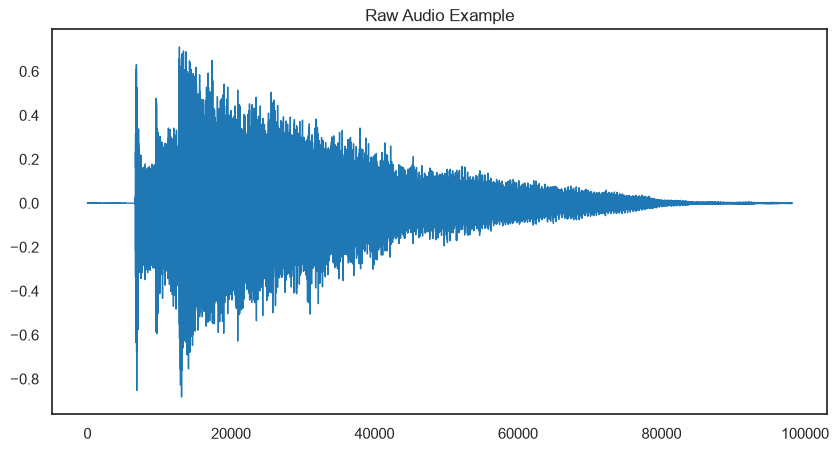

In [83]:
pd.Series(y).plot(figsize=(10, 5), 
                  lw=1, 
                  title="Raw Audio Example",
                  color = color_pal[0])
plt.show()

Cut out some parts of the audio

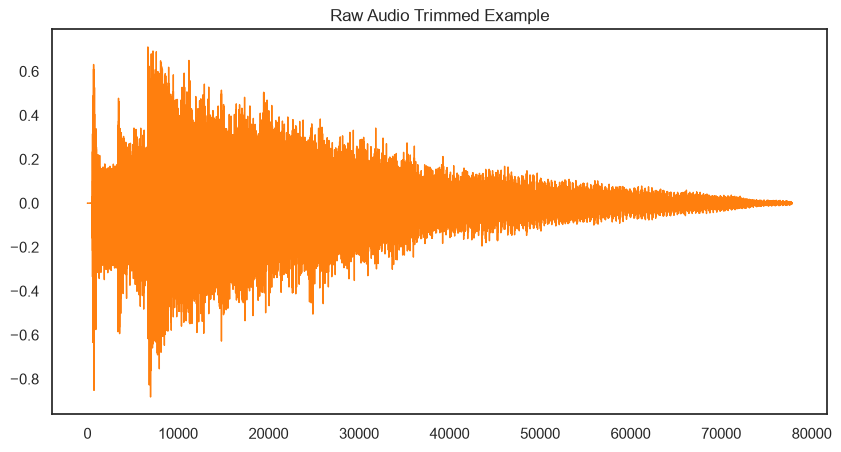

In [86]:
y_trimmed, _ = librosa.effects.trim(y, top_db=40)
pd.Series(y_trimmed).plot(figsize=(10, 5), 
                  lw=1, 
                  title="Raw Audio Trimmed Example",
                  color = color_pal[1])
plt.show()

Get really zoomed in

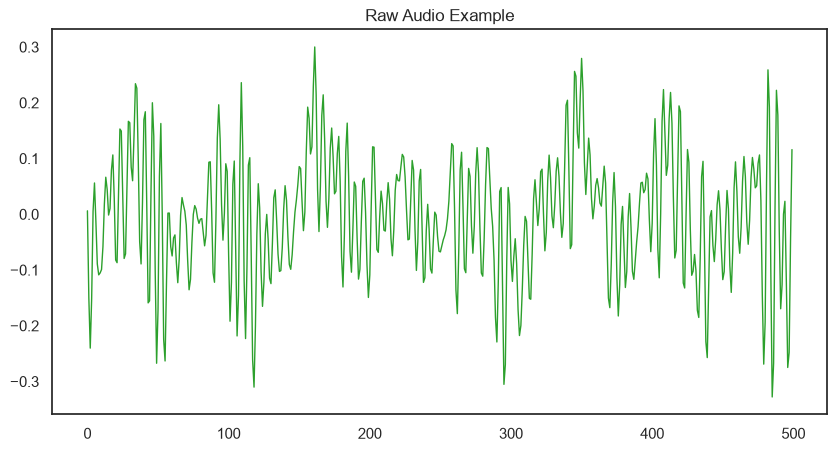

In [87]:
pd.Series(y[30000: 30500]).plot(figsize=(10, 5), 
                  lw=1, 
                  title="Raw Audio Example",
                  color = color_pal[2])
plt.show()

Examine the strength of frequencies....extract out what freq are present at different parts of the audio-----Spectogram

In [88]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db.shape

(1025, 192)

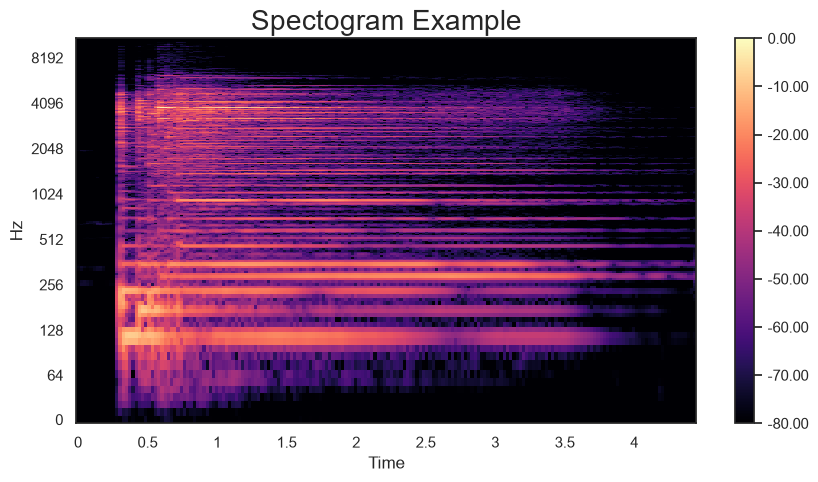

In [89]:
#plot the transformed audio data
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db, x_axis="time", y_axis="log", ax=ax)

ax.set_title("Spectogram Example", fontsize = 20)
fig.colorbar(img, ax=ax, format=f"%0.2f")
plt.show()

In [92]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S.shape
S_db_mel = librosa.amplitude_to_db(S, ref=np.max)
print(S_db_mel)

[[-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]
 ...
 [-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]]


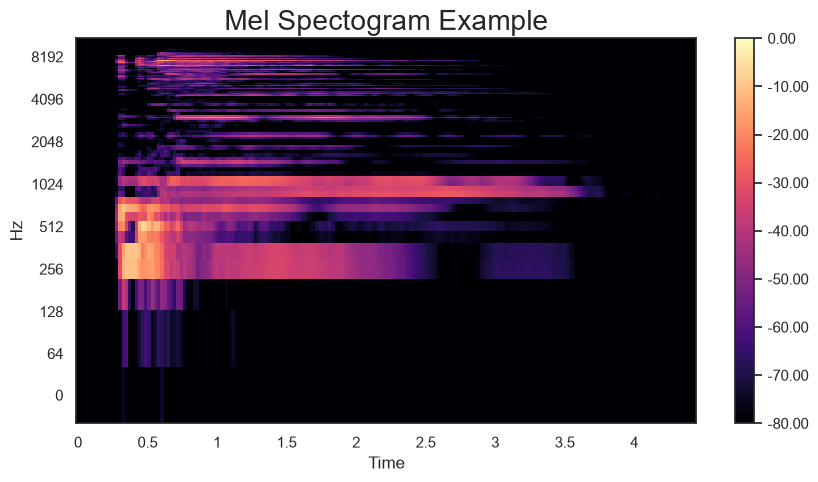

In [91]:
#Plot the mel spectogram
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db_mel, x_axis="time", y_axis="log", ax=ax)

ax.set_title("Mel Spectogram Example", fontsize = 20)
fig.colorbar(img, ax=ax, format=f"%0.2f")
plt.show()